# Notebook 6 — Analyse statistique des extrêmes
## Ajustement de lois (GEV, Gumbel, Lognormale) sur les maxima annuels

---

## Objectif

Ce notebook ajuste des **lois statistiques extrêmes** sur les maxima annuels  
d'intensité pour calculer les **valeurs de retour** (intensités associées à des  
périodes de retour de 2, 5, 10, 20, 50, 100 ans).

### Théorie des valeurs extrêmes

La théorie des valeurs extrêmes (EVT) stipule que les maxima annuels d'une  
variable suivent asymptotiquement une loi **GEV (Gumbel, Fréchet ou Weibull)** :

$$F(x) = \exp\left[-\left(1 + \xi \frac{x - \mu}{\sigma}\right)^{-1/\xi}\right]$$

où :
- $\mu$ = paramètre de localisation (position)
- $\sigma$ = paramètre d'échelle (dispersion)
- $\xi$ = paramètre de forme (shape)

| $\xi$ | Loi | Description |
|-------|-----|-------------|
| $\xi = 0$ | **Gumbel** | Cas le plus fréquent en hydrologie |
| $\xi > 0$ | **Fréchet** | Queue lourde (extrêmes très élevés) |
| $\xi < 0$ | **Weibull** | Borne supérieure finie |

### Loi retenue

On teste 3 lois et on retient celle avec l'**AIC minimal** (critère d'Akaike) :  
AIC = $-2 \ln(L) + 2k$ où $L$ = vraisemblance et $k$ = nombre de paramètres.

### Livrables

| Fichier | Contenu |
|---------|--------|
| `figures/n6/fig1_lois_ajustees.png` | PDF des 3 lois sur l'histogramme |
| `figures/n6/fig2_qqplot.png` | Q-Q plots (positions de Gringorten) |
| `figures/n6/fig3_periodes_retour.png` | Courbes de valeurs de retour |
| `figures/n6/fig4_intervalles_confiance.png` | IC 95% Bootstrap |

---
**Auteur :** AY2K  
**Encadreur :** Prof. Titembaye Donald  
**Établissement :** École Polytechnique de Lomé (EPL)  
**Projet :** Modélisation des courbes IDF — Station de Kara, Nord Togo  

## 0. Configuration et imports

In [1]:
import os
import warnings

warnings.filterwarnings('ignore')

NB = 'n6'
FIG_DIR = f'figures/{NB}'
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Répertoire figures : {FIG_DIR}')

Répertoire figures : figures/n6


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'figure.dpi':       100,
})

print('Imports chargés')

Imports chargés


---
## Section 1 — Chargement et extraction des maxima annuels

On charge la série complète (1980–présent) et on extrait le **maximum annuel**  
d'intensité. Ces maxima annuels sont la base de l'analyse des extrêmes.

In [3]:
df = pd.read_csv('data/serie_complete.csv', parse_dates=['date'])
print(f'Série complète : {len(df)} lignes | {df.date.min().date()} → {df.date.max().date()}')

df['annee'] = df['date'].dt.year

# Maxima annuels d'intensité (mm/h)
maxima = df.groupby('annee')['intensite_max_mm_h'].max().dropna().reset_index()
maxima.columns = ['annee', 'imax_mm_h']
maxima = maxima.sort_values('annee').reset_index(drop=True)

print(f'\nMaxima annuels : {len(maxima)} années')
print(f'Min    : {maxima.imax_mm_h.min():.1f} mm/h')
print(f'Max    : {maxima.imax_mm_h.max():.1f} mm/h')
print(f'Moyenne: {maxima.imax_mm_h.mean():.1f} mm/h')
print(f'Écart-type: {maxima.imax_mm_h.std():.1f} mm/h')
print(f'\nTableau des maxima :')
print(maxima.to_string())

Série complète : 3012 lignes | 1980-01-21 → 2014-11-30

Maxima annuels : 35 années
Min    : 13.7 mm/h
Max    : 363.8 mm/h
Moyenne: 117.8 mm/h
Écart-type: 98.1 mm/h

Tableau des maxima :
    annee   imax_mm_h
0    1980  157.745045
1    1981  170.416893
2    1982  127.670406
3    1983  119.902949
4    1984  152.517889
5    1985  176.392350
6    1986  154.006967
7    1987  184.560031
8    1988  216.387432
9    1989  152.787591
10   1990  212.881734
11   1991  363.761803
12   1992  133.686738
13   1993  163.649531
14   1994  183.912694
15   1995  200.954840
16   1996  253.517201
17   1997  328.668375
18   1998  219.373182
19   1999  153.441276
20   2000   19.190987
21   2001   13.665398
22   2002   19.578107
23   2003   19.457722
24   2004   22.619531
25   2005   19.535489
26   2006   19.888163
27   2007   15.475120
28   2008   18.996545
29   2009   21.890766
30   2010   20.826858
31   2011   19.683464
32   2012   23.722138
33   2013   21.793866
34   2014   22.162357


---
## Section 2 — Ajustement des lois statistiques

### Loi GEV (Généralisée des Valeurs Extrêmes)

La GEV est la loi la plus générale pour les maxima. Elle englobe :
- Gumbel (shape $\xi = 0$)
- Fréchet (shape $\xi > 0$)
- Weibull (shape $\xi < 0$)

### Loi de Gumbel

Cas particulier de la GEV avec $\xi = 0$. C'est la loi la plus utilisée en  
hydrologie pour les maxima annuels. Elle a 2 paramètres (loc, scale).

### Loi Log-normale

Loi classique pour les données positives asymétriques. Elle aussi a 2 paramètres.

### Critère de sélection : AIC

$$AIC = -2 \ln(L) + 2k$$

L'AIC pénalise les modèles complexes (plus de paramètres). La loi avec l'AIC  
le plus faible est retenue.

In [4]:
data = maxima['imax_mm_h'].values
n = len(data)

def aic_bic(log_lik, k, n):
    """Calcule AIC et BIC à partir de la log-vraisemblance."""
    aic = -2 * log_lik + 2 * k
    bic = -2 * log_lik + k * np.log(n)
    return aic, bic

resultats_lois = []

# --- GEV (3 paramètres) ---
try:
    gev_params = sp_stats.genextreme.fit(data)
    gev_ll = np.sum(sp_stats.genextreme.logpdf(data, *gev_params))
    gev_aic, gev_bic = aic_bic(gev_ll, 3, n)
    resultats_lois.append({'Loi': 'GEV', 'Paramètres': gev_params,
                           'AIC': gev_aic, 'BIC': gev_bic, 'dist': sp_stats.genextreme})
    print(f'GEV : shape={gev_params[0]:.3f}, loc={gev_params[1]:.2f}, '
          f'scale={gev_params[2]:.2f} | AIC={gev_aic:.1f}')
except Exception as e:
    print(f'GEV non convergée : {e}')

# --- Gumbel (2 paramètres) ---
try:
    gum_params = sp_stats.gumbel_r.fit(data)
    gum_ll = np.sum(sp_stats.gumbel_r.logpdf(data, *gum_params))
    gum_aic, gum_bic = aic_bic(gum_ll, 2, n)
    resultats_lois.append({'Loi': 'Gumbel', 'Paramètres': gum_params,
                           'AIC': gum_aic, 'BIC': gum_bic, 'dist': sp_stats.gumbel_r})
    print(f'Gumbel : loc={gum_params[0]:.2f}, scale={gum_params[1]:.2f} | AIC={gum_aic:.1f}')
except Exception as e:
    print(f'Gumbel non ajustée : {e}')

# --- Lognormale (2 paramètres) ---
try:
    ln_params = sp_stats.lognorm.fit(data, floc=0)
    ln_ll = np.sum(sp_stats.lognorm.logpdf(data, *ln_params))
    ln_aic, ln_bic = aic_bic(ln_ll, 2, n)
    resultats_lois.append({'Loi': 'Lognormale', 'Paramètres': ln_params,
                           'AIC': ln_aic, 'BIC': ln_bic, 'dist': sp_stats.lognorm})
    print(f'Lognormale : shape={ln_params[0]:.3f}, scale={ln_params[2]:.2f} | AIC={ln_aic:.1f}')
except Exception as e:
    print(f'Lognormale non ajustée : {e}')

# Sélection par AIC minimal
df_lois = pd.DataFrame([{k: v for k, v in r.items() if k != 'dist'} for r in resultats_lois])
df_lois = df_lois.sort_values('AIC').reset_index(drop=True)
best_loi = df_lois.iloc[0]['Loi']
best_loi_dict = next(r for r in resultats_lois if r['Loi'] == best_loi)

print(f'\n=== Classement AIC ===')
print(df_lois[['Loi', 'AIC', 'BIC']].to_string(index=False))
print(f'\n→ Loi retenue : {best_loi} (AIC minimal)')

GEV : shape=-1.533, loc=31.39, scale=29.80 | AIC=408.9
Gumbel : loc=72.20, scale=76.54 | AIC=419.4
Lognormale : shape=1.127, scale=70.50 | AIC=409.6

=== Classement AIC ===
       Loi        AIC        BIC
       GEV 408.859287 413.525331
Lognormale 409.596686 412.707382
    Gumbel 419.395464 422.506160

→ Loi retenue : GEV (AIC minimal)


---
## Section 3 — Valeurs de retour

La **valeur de retour** $x_T$ est l'intensité associée à une période de retour $T$ ans :  
c'est la valeur qui est dépassée en moyenne une fois tous les $T$ ans.

$$P(X > x_T) = \frac{1}{T} \quad \Leftrightarrow \quad x_T = F^{-1}\left(1 - \frac{1}{T}\right)$$

In [5]:
periodes = [2, 5, 10, 20, 50, 100]
proba_depassement = [1 - 1/T for T in periodes]

tableau_retour = {'Période (ans)': periodes}
for r in resultats_lois:
    try:
        vals = [r['dist'].ppf(p, *r['Paramètres']) for p in proba_depassement]
        tableau_retour[r['Loi']] = [round(v, 1) for v in vals]
    except Exception as e:
        tableau_retour[r['Loi']] = ['N/A'] * len(periodes)

df_retour = pd.DataFrame(tableau_retour)
print('=== Valeurs de retour (mm/h) ===')
print(df_retour.to_string(index=False))

=== Valeurs de retour (mm/h) ===
 Période (ans)     GEV  Gumbel  Lognormale
             2    46.0   100.3        70.5
             5   205.7   187.0       182.0
            10   623.7   244.4       298.9
            20  1855.7   299.5       450.2
            50  7700.3   370.8       713.8
           100 22427.0   424.3       970.5


---
## Section 4 — Figures

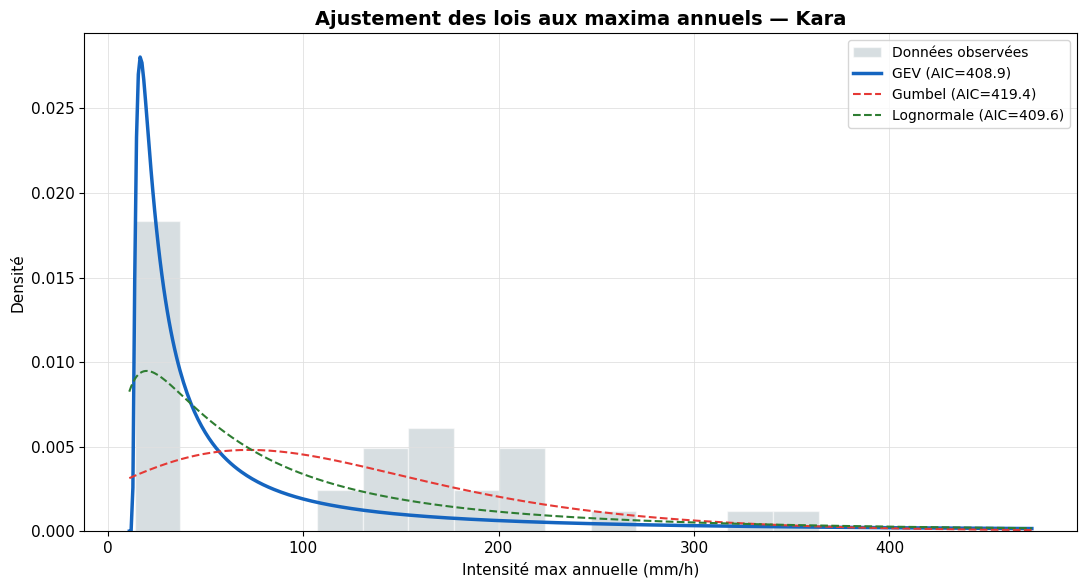

fig1 sauvegardée


In [6]:
# ==============================================================================
# FIGURE 1 — Ajustement des lois sur les maxima annuels
# ==============================================================================

x_range = np.linspace(data.min() * 0.8, data.max() * 1.3, 500)
colors_lois = {'GEV': '#1565C0', 'Gumbel': '#E53935', 'Lognormale': '#2E7D32'}

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(data, bins=15, density=True, alpha=0.5, color='#B0BEC5', edgecolor='white',
        label='Données observées')

for r in resultats_lois:
    try:
        pdf_vals = r['dist'].pdf(x_range, *r['Paramètres'])
        style = '-' if r['Loi'] == best_loi else '--'
        lw = 2.5 if r['Loi'] == best_loi else 1.5
        ax.plot(x_range, pdf_vals, style, color=colors_lois.get(r['Loi'], 'black'),
                linewidth=lw, label=f"{r['Loi']} (AIC={r['AIC']:.1f})")
    except Exception as e:
        print(f'Erreur PDF {r["Loi"]}: {e}')

ax.set_xlabel('Intensité max annuelle (mm/h)')
ax.set_ylabel('Densité')
ax.set_title('Ajustement des lois aux maxima annuels — Kara', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_lois_ajustees.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig1 sauvegardée')

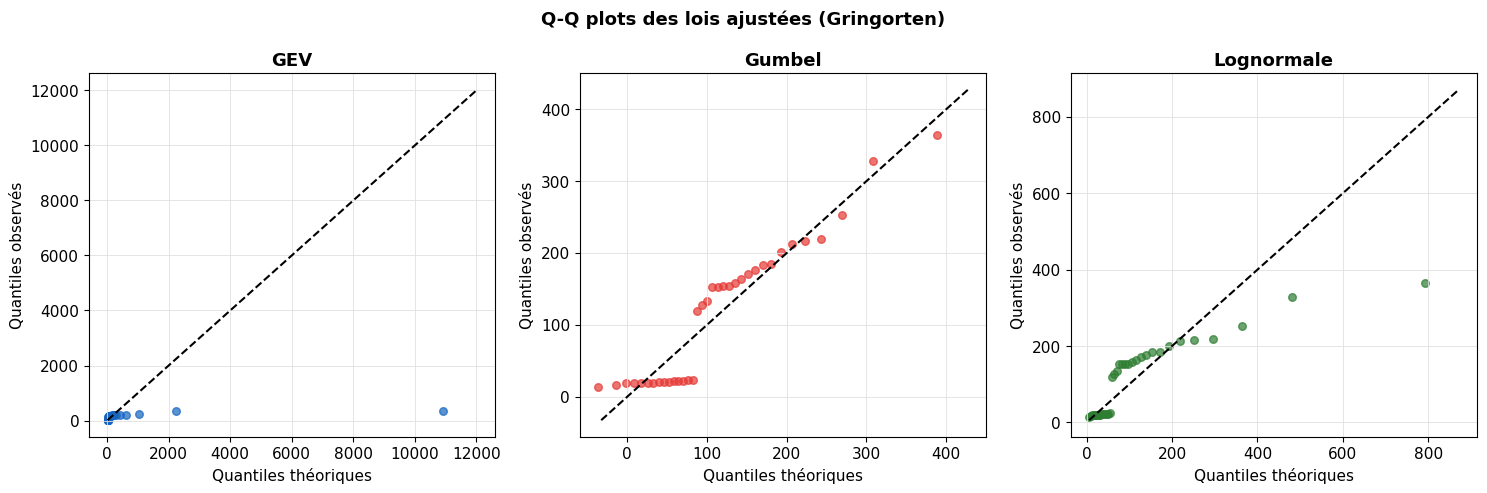

fig2 sauvegardée


In [7]:
# ==============================================================================
# FIGURE 2 — Q-Q plots (positions de Gringorten)
# ==============================================================================
# Les positions de Gringorten : (i - 0.44) / (n + 0.12)
# Formule recommandée pour les maxima annuels en hydrologie.

n_lois = len(resultats_lois)
fig, axes = plt.subplots(1, n_lois, figsize=(5 * n_lois, 5))
if n_lois == 1:
    axes = [axes]

data_sorted = np.sort(data)
pp = (np.arange(1, n + 1) - 0.44) / (n + 0.12)  # Gringorten

for ax, r in zip(axes, resultats_lois):
    try:
        theoriques = r['dist'].ppf(pp, *r['Paramètres'])
        ax.scatter(theoriques, data_sorted, s=30, alpha=0.7,
                   color=colors_lois.get(r['Loi'], 'steelblue'))
        lim_min = min(theoriques.min(), data_sorted.min()) * 0.9
        lim_max = max(theoriques.max(), data_sorted.max()) * 1.1
        ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1.5)
        ax.set_xlabel('Quantiles théoriques')
        ax.set_ylabel('Quantiles observés')
        ax.set_title(f'{r["Loi"]}', fontweight='bold')
    except Exception as e:
        ax.set_title(f'{r["Loi"]} (erreur: {e})')

plt.suptitle('Q-Q plots des lois ajustées (Gringorten)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_qqplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig2 sauvegardée')

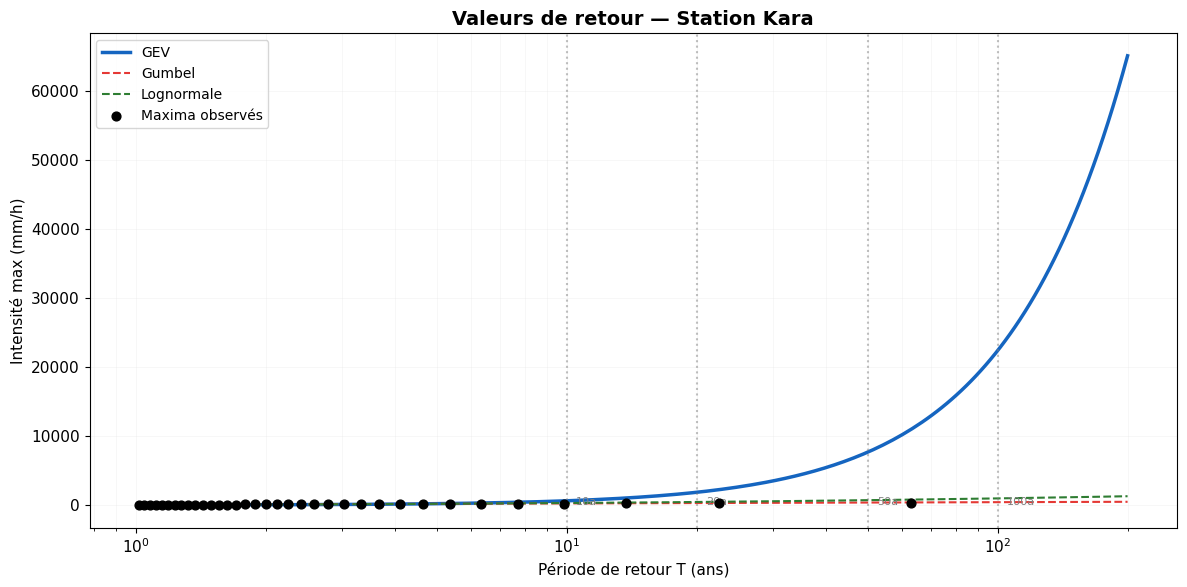

fig3 sauvegardée


In [8]:
# ==============================================================================
# FIGURE 3 — Courbes de valeurs de retour
# ==============================================================================

T_range = np.logspace(np.log10(1.1), np.log10(200), 200)
p_range = 1 - 1/T_range

fig, ax = plt.subplots(figsize=(12, 6))
for r in resultats_lois:
    try:
        vr = [r['dist'].ppf(p, *r['Paramètres']) for p in p_range]
        style = '-' if r['Loi'] == best_loi else '--'
        lw = 2.5 if r['Loi'] == best_loi else 1.5
        ax.plot(T_range, vr, style, color=colors_lois.get(r['Loi'], 'black'),
                linewidth=lw, label=r['Loi'])
    except:
        pass

# Points observés (Gringorten)
T_obs = 1 / (1 - pp)
ax.scatter(T_obs, data_sorted, zorder=5, color='black', s=40, label='Maxima observés')

# Lignes verticales périodes standard
for T in [10, 20, 50, 100]:
    ax.axvline(T, color='grey', linestyle=':', alpha=0.5)
    ax.text(T * 1.05, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
            f'{T}a', fontsize=8, color='grey')

ax.set_xscale('log')
ax.set_xlabel('Période de retour T (ans)')
ax.set_ylabel('Intensité max (mm/h)')
ax.set_title('Valeurs de retour — Station Kara', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_periodes_retour.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig3 sauvegardée')

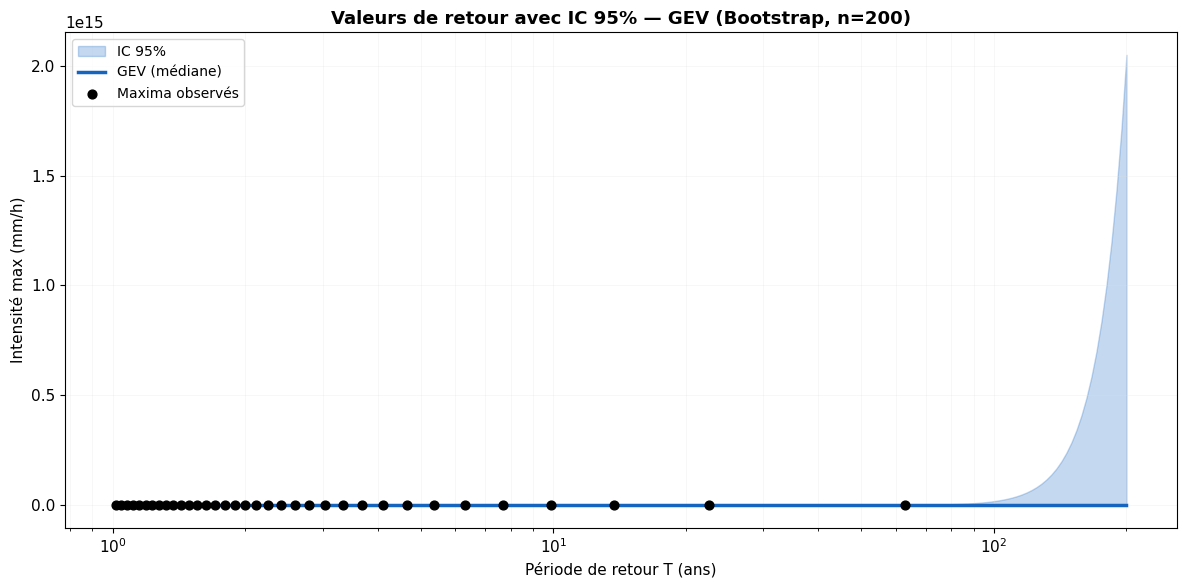

fig4 sauvegardée


In [9]:
# ==============================================================================
# FIGURE 4 — Intervalles de confiance 95% (Bootstrap)
# ==============================================================================
# Le Bootstrap est une méthode non-paramétrique pour estimer l'incertitude.
# On rééchantillonne les données n=500 fois, on réajuste la loi retenue,
# et on calcule les quantiles pour chaque rééchantillonnage.

N_BOOTSTRAP = 200
best_r = best_loi_dict
vr_bootstrap = np.zeros((N_BOOTSTRAP, len(T_range)))

np.random.seed(42)
for i in range(N_BOOTSTRAP):
    sample = np.random.choice(data, size=len(data), replace=True)
    try:
        params_b = best_r['dist'].fit(sample)
        vr_bootstrap[i] = [best_r['dist'].ppf(p, *params_b) for p in p_range]
    except:
        vr_bootstrap[i] = np.nan

vr_median = np.nanpercentile(vr_bootstrap, 50, axis=0)
vr_lower  = np.nanpercentile(vr_bootstrap, 2.5, axis=0)
vr_upper  = np.nanpercentile(vr_bootstrap, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(T_range, vr_lower, vr_upper, alpha=0.25, color='#1565C0', label='IC 95%')
ax.plot(T_range, vr_median, '-', color='#1565C0', linewidth=2.5,
        label=f'{best_loi} (médiane)')
ax.scatter(T_obs, data_sorted, zorder=10, color='black', s=40, label='Maxima observés')
ax.set_xscale('log')
ax.set_xlabel('Période de retour T (ans)')
ax.set_ylabel('Intensité max (mm/h)')
ax.set_title(f'Valeurs de retour avec IC 95% — {best_loi} (Bootstrap, n={N_BOOTSTRAP})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig4_intervalles_confiance.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig4 sauvegardée')

---
## Résumé

| Indicateur | Valeur |
|------------|--------|
| Source | `data/serie_complete.csv` |
| Loi retenue | Sélectionnée par AIC minimal |
| Périodes de retour | 2, 5, 10, 20, 50, 100 ans |
| IC 95% | Bootstrap (n=500) |
| Livrables | 4 figures dans `figures/n6/` |
| Suivant | `n7_courbes_idf.ipynb` |

---
*Fin du Notebook 6*